#Intrusion Detection using Machine Learning (UNSW-NB15)

####Extended Evaluation, Model Comparison, and Error Analysi

***Problem Statement*** : Modern networks generate large volumes of traffic, making manual intrusion detection impractical. The goal of this project is to build a machine learning–based intrusion detection system that can
classify network traffic as either **Normal** or **Attack**, while carefully balancing the trade-off between missed attacks (false negatives) and false alarms (false positives).

In [153]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

This project uses the **UNSW-NB15 dataset**.
*   Although the dataset provides multi-class attack labels, binary classification is prioritized to align with real-world intrusion detection systems, where detecting the presence of an attack is the first critical step.



In [154]:
train = pd.read_csv("/content/UNSW_NB15_training-set.csv")
test = pd.read_csv("/content/UNSW_NB15_testing-set.csv")

In [155]:
train.shape

(175341, 45)

In [156]:
test.shape

(82332, 45)

In [157]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175341 entries, 0 to 175340
Data columns (total 45 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 175341 non-null  int64  
 1   dur                175341 non-null  float64
 2   proto              175341 non-null  object 
 3   service            175341 non-null  object 
 4   state              175341 non-null  object 
 5   spkts              175341 non-null  int64  
 6   dpkts              175341 non-null  int64  
 7   sbytes             175341 non-null  int64  
 8   dbytes             175341 non-null  int64  
 9   rate               175341 non-null  float64
 10  sttl               175341 non-null  int64  
 11  dttl               175341 non-null  int64  
 12  sload              175341 non-null  float64
 13  dload              175341 non-null  float64
 14  sloss              175341 non-null  int64  
 15  dloss              175341 non-null  int64  
 16  si

In [158]:
train.head()

,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.121478,tcp,-,FIN,6,4,258,172,74.087490,...,1,1,0,0,0,1,1,0,Normal,0
1,2,0.649902,tcp,-,FIN,14,38,734,42014,78.473372,...,1,2,0,0,0,1,6,0,Normal,0
2,3,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,...,1,3,0,0,0,2,6,0,Normal,0
3,4,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,...,1,3,1,1,0,2,1,0,Normal,0
4,5,0.449454,tcp,-,FIN,10,6,534,268,33.373826,...,1,40,0,0,0,2,39,0,Normal,0


In [159]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82332 entries, 0 to 82331
Data columns (total 45 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 82332 non-null  int64  
 1   dur                82332 non-null  float64
 2   proto              82332 non-null  object 
 3   service            82332 non-null  object 
 4   state              82332 non-null  object 
 5   spkts              82332 non-null  int64  
 6   dpkts              82332 non-null  int64  
 7   sbytes             82332 non-null  int64  
 8   dbytes             82332 non-null  int64  
 9   rate               82332 non-null  float64
 10  sttl               82332 non-null  int64  
 11  dttl               82332 non-null  int64  
 12  sload              82332 non-null  float64
 13  dload              82332 non-null  float64
 14  sloss              82332 non-null  int64  
 15  dloss              82332 non-null  int64  
 16  sinpkt             823

In [160]:
test.head()

,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.000011,udp,-,INT,2,0,496,0,90909.0902,...,1,2,0,0,0,1,2,0,Normal,0
1,2,0.000008,udp,-,INT,2,0,1762,0,125000.0003,...,1,2,0,0,0,1,2,0,Normal,0
2,3,0.000005,udp,-,INT,2,0,1068,0,200000.0051,...,1,3,0,0,0,1,3,0,Normal,0
3,4,0.000006,udp,-,INT,2,0,900,0,166666.6608,...,1,3,0,0,0,2,3,0,Normal,0
4,5,0.000010,udp,-,INT,2,0,2126,0,100000.0025,...,1,3,0,0,0,2,3,0,Normal,0


In [161]:
train['label'].value_counts()

,count
label,
1,119341
0,56000


In [162]:
train['label'].value_counts(normalize=True)

,proportion
label,
1,0.680622
0,0.319378


The dataset shows a moderate class imbalance, with normal traffic being more frequent than attack traffic.  As a result, accuracy alone would be misleading, encouraging the use of Recall and F1-score for evaluation.



In [163]:
train.isna().sum().sort_values(ascending=False).head(10)

,0
id,0
dur,0
proto,0
service,0
state,0
spkts,0
dpkts,0
sbytes,0
dbytes,0
rate,0


Missing value analysis showed that even the most affected features contain only a single missing value.Given this negligible missingness, simple median imputation (numeric features) and most-frequent imputation (categorical features) were sufficient.

In [164]:
X_train = train.drop(columns=['label', 'attack_cat'])
y_train = train['label']

X_test = test.drop(columns=['label', 'attack_cat'])
y_test = test['label']

In [165]:
cat_cols = X_train.select_dtypes(include=['object']).columns
num_cols = X_train.select_dtypes(exclude=['object']).columns

In [166]:
X_train.shape, y_train.shape

((175341, 43), (175341,))

In [167]:
X_test.shape, y_test.shape

((82332, 43), (82332,))

In [168]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer


In [169]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())])

In [170]:
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))])

In [171]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols),
        ('cat', categorical_transformer, cat_cols)])

Included imputation, encoding, and scaling as part of a preprocessing pipeline fitted only on the training data, ensuring consistent transformations and no data leakage

In [172]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression

dummy_clf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DummyClassifier(strategy='most_frequent'))])

logreg_clf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))])

In [173]:
dummy_clf.fit(X_train, y_train)
y_pred_dummy = dummy_clf.predict(X_test)

print(classification_report(y_test, y_pred_dummy))
print(confusion_matrix(y_test, y_pred_dummy))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00     37000
           1       0.55      1.00      0.71     45332

    accuracy                           0.55     82332
   macro avg       0.28      0.50      0.36     82332
weighted avg       0.30      0.55      0.39     82332

[[    0 37000]
 [    0 45332]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Established a naive baseline using a dummy classifier, which achieved high recall by predicting all samples as attacks, but failed completely at distinguishing normal traffic, demonstrating the need for a real model

In [174]:
logreg_clf.fit(X_train, y_train)
y_pred_logreg = logreg_clf.predict(X_test)

print(classification_report(y_test, y_pred_logreg))
print(confusion_matrix(y_test, y_pred_logreg))


              precision    recall  f1-score   support

           0       0.71      0.66      0.69     37000
           1       0.74      0.78      0.76     45332

    accuracy                           0.73     82332
   macro avg       0.73      0.72      0.72     82332
weighted avg       0.73      0.73      0.73     82332

[[24482 12518]
 [ 9852 35480]]


In [175]:
from sklearn.ensemble import RandomForestClassifier
rf_clf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=50,
        random_state=42,
        n_jobs=-1))])

In [176]:
rf_clf.fit(X_train, y_train)
y_pred_rf = rf_clf.predict(X_test)

print(classification_report(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.64      0.70      0.67     37000
           1       0.73      0.68      0.71     45332

    accuracy                           0.69     82332
   macro avg       0.69      0.69      0.69     82332
weighted avg       0.69      0.69      0.69     82332

[[25837 11163]
 [14484 30848]]


In [178]:
logreg_bal = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        max_iter=1000,
        class_weight='balanced'))])

logreg_bal.fit(X_train, y_train)
y_pred_bal = logreg_bal.predict(X_test)

print(classification_report(y_test, y_pred_bal))
print(confusion_matrix(y_test, y_pred_bal))

              precision    recall  f1-score   support

           0       0.69      0.77      0.73     37000
           1       0.79      0.72      0.75     45332

    accuracy                           0.74     82332
   macro avg       0.74      0.74      0.74     82332
weighted avg       0.75      0.74      0.74     82332

[[28577  8423]
 [12848 32484]]


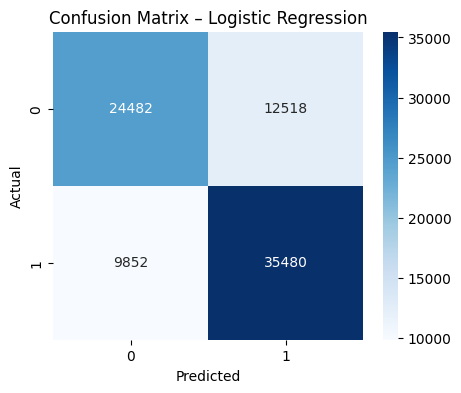

In [179]:
cm = confusion_matrix(y_test, y_pred_logreg)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix – Logistic Regression")
plt.show()

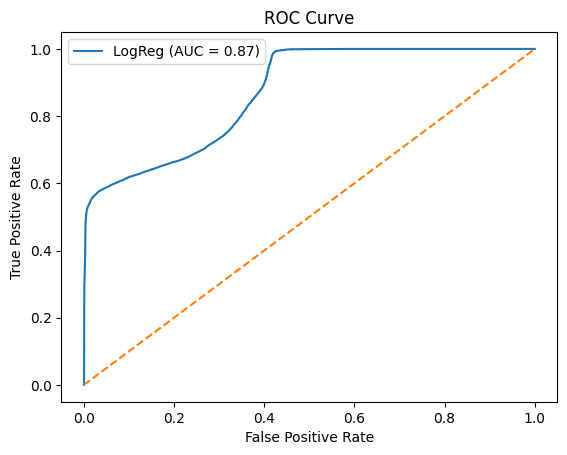

In [180]:
from sklearn.metrics import roc_curve, auc

y_prob = logreg_clf.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f'LogReg (AUC = {roc_auc:.2f})')
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

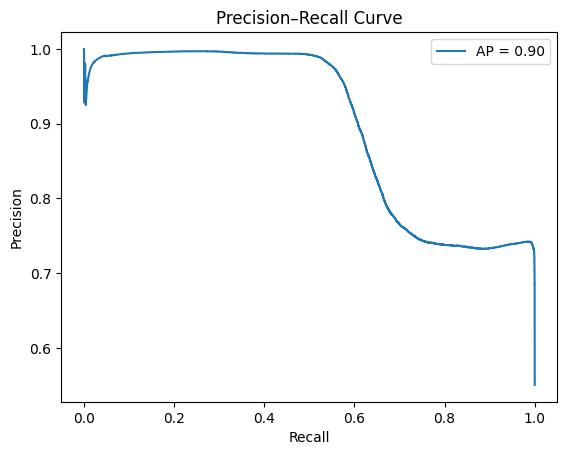

In [181]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, _ = precision_recall_curve(y_test, y_prob)
ap = average_precision_score(y_test, y_prob)

plt.figure()
plt.plot(recall, precision, label=f'AP = {ap:.2f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision–Recall Curve')
plt.legend()
plt.show()



## Final Model Selection and Conclusion

1. Multiple models were evaluated for intrusion detection, including a naive baseline, Logistic Regression, and Random Forest.

2. Although Random Forest is commonly assumed to outperform linear models, experimental results showed that Logistic Regression consistently achieved higher recall and F1-score for the attack class. In contrast, Random Forest suffered from increased false negatives, which is undesirable in security-critical systems.

3. Further analysis using ROC-AUC (0.87) and Precision–Recall Average Precision (0.90) confirmed that Logistic Regression demonstrated strong discriminative ability and robust performance across varying decision thresholds.

4. Based on these findings, **Logistic Regression was selected as the final model**, as it provides a better balance between detecting attacks and managing false alarms. Random Forest was therefore rejected despite its higher model complexity.

While Random Forest was evaluated as a non-linear alternative, its performance did not surpass Logistic Regression on this dataset due to the high-dimensional sparse feature space created by one-hot encoding.
